In [6]:
import torch
import lightning as L
from sklearn.datasets import make_moons
from dal_toolbox.active_learning import ActiveLearningDataModule
from dal_toolbox.models.deterministic import DeterministicModel
from dal_toolbox.active_learning.strategies import LeastConfidentSampling
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net

In [7]:
from dal_toolbox.utils import seed_everything
from notebook_utils import dataset_to_xy, plot_contour
import pylab as plt
seed_everything(2)

Seed set to 2


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
----

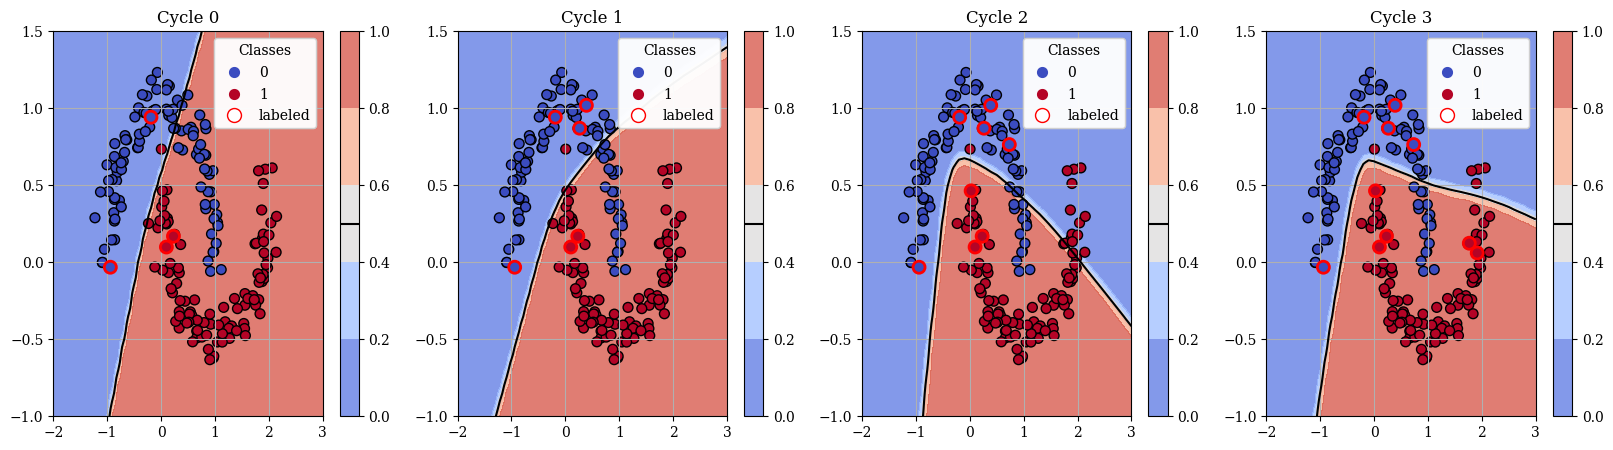

In [8]:
# Create the twoo moons dataset
X, y = make_moons(200, noise=.1, random_state=42)

# Transform into a TensorDataset
X, y = torch.tensor(X).float(), torch.tensor(y).long()
tensor_dataset = torch.utils.data.TensorDataset(X, y)

# Setup the AL-Datamodule provided by the dal_toolbox and initialize with four randomly labeled samples
al_datamodule = ActiveLearningDataModule(tensor_dataset, train_batch_size=32)
al_datamodule.random_init(n_samples=4, class_balanced=True)

# Initialize a model and wrap it with the DeterministicModel Wrapper provided by the DAL-Toolbox
model = Net(dropout_rate=0., num_classes=2)
model = DeterministicModel(model, optimizer=torch.optim.SGD(model.parameters(), lr=1e-1, momentum=.9))

# Initialize an AL-Strategy
al_strategy = LeastConfidentSampling()

# Figure for plotting
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20,5))

# Perfom AL-Cycles
for i_cycle in range(4):
    # Acquire new Labels
    if i_cycle != 0:
        indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=2)
        al_datamodule.update_annotations(indices)

    # Refit the model on the labeled data
    model.reset_states()
    trainer = L.Trainer(max_epochs=50, enable_progress_bar=False)
    trainer.fit(model, al_datamodule)

    # PLotting
    X, y = dataset_to_xy(al_datamodule.query_dataset)
    X_l, y_l = X[al_datamodule.labeled_indices], y[al_datamodule.labeled_indices]
    X_u, y_u = X[al_datamodule.unlabeled_indices], y[al_datamodule.unlabeled_indices]
    plot_contour(model, X_l=X_l, y_l=y_l, X_u=X_u, y_u=y_u, x_domain=(-2,3), y_domain=(-1, 1.5), ax=ax[i_cycle])
    ax[i_cycle].set_title(f"Cycle {i_cycle}")
#plt.show()
plt.savefig('readme_example_1.png')


In [9]:
spectral_norm_params = dict(
    norm_bound=.9,
    n_power_iterations=1
)
gp_params = dict(
    num_inducing=1024,
    kernel_scale=0.05,
    random_feature_type='orf',
    scale_random_features=False
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleSNGP       | 101 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.406     Total estimated model params size (MB)


`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleSNGP       | 101 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.406     Total estimated model params size (MB)
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
----

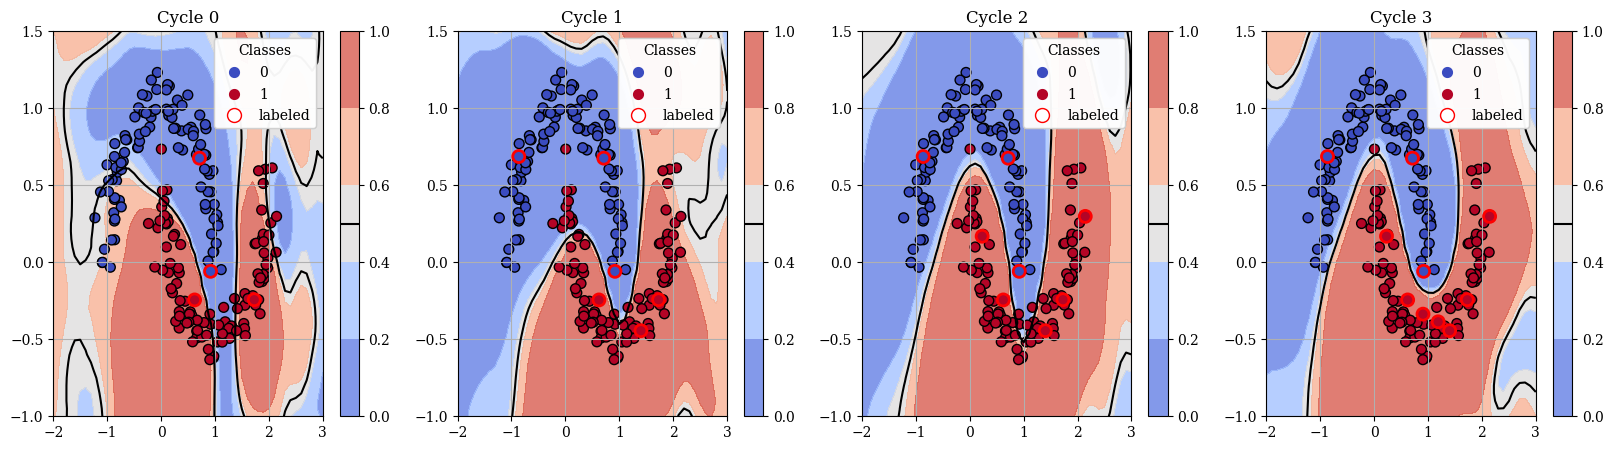

In [10]:
from dal_toolbox.models.sngp import SNGPModel
from dal_toolbox.models.deterministic.simplenet import SimpleSNGP as SNGPNet

# Setup the AL-Datamodule provided by the dal_toolbox and initialize with four randomly labeled samples
al_datamodule = ActiveLearningDataModule(tensor_dataset, train_batch_size=128)
al_datamodule.random_init(n_samples=4, class_balanced=True)

# Initialize a model and wrap it with the DeterministicModel Wrapper provided by the DAL-Toolbox
model = SNGPNet(num_classes=2, use_spectral_norm=True, spectral_norm_params=spectral_norm_params, gp_params=gp_params)
model = SNGPModel(model, optimizer=torch.optim.SGD(model.parameters(),  lr=1e-2, weight_decay=1e-2, momentum=.9))

# Initialize an AL-Strategy
al_strategy = LeastConfidentSampling()

# Figure for plotting
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20,5))

# Perfom AL-Cycles
for i_cycle in range(4):
    # Acquire new Labels
    if i_cycle != 0:
        indices = al_strategy.query(model=model, al_datamodule=al_datamodule, acq_size=2)
        al_datamodule.update_annotations(indices)

    # Refit the model on the labeled data
    model.reset_states()
    trainer = L.Trainer(max_epochs=50, enable_progress_bar=False)
    trainer.fit(model, al_datamodule)

    # PLotting
    X, y = dataset_to_xy(al_datamodule.query_dataset)
    X_l, y_l = X[al_datamodule.labeled_indices], y[al_datamodule.labeled_indices]
    X_u, y_u = X[al_datamodule.unlabeled_indices], y[al_datamodule.unlabeled_indices]
    plot_contour(model, X_l=X_l, y_l=y_l, X_u=X_u, y_u=y_u, x_domain=(-2,3), y_domain=(-1, 1.5), ax=ax[i_cycle])
    ax[i_cycle].set_title(f"Cycle {i_cycle}")
#plt.show()
plt.savefig('readme_example_2.png')